In [3]:
# ==========================================
# CREDIT CARD FRAUD DETECTION PROJECT
# ==========================================

# Import libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Load dataset

df = pd.read_csv("creditcard.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
# Display first five rows

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Dataset shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 284807
Columns : 31


In [7]:
# Check missing values

df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


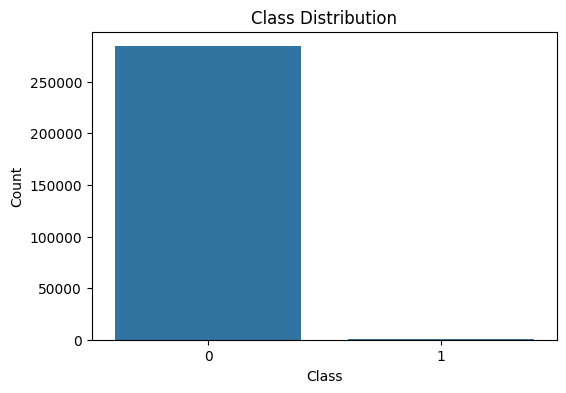

In [9]:
# ==========================================
# Class Distribution Plot
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

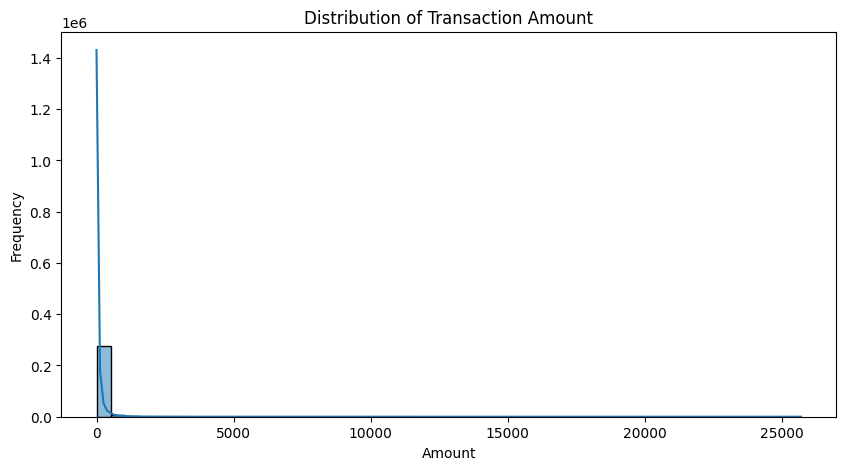

In [10]:
# ==========================================
# Transaction Amount Distribution
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

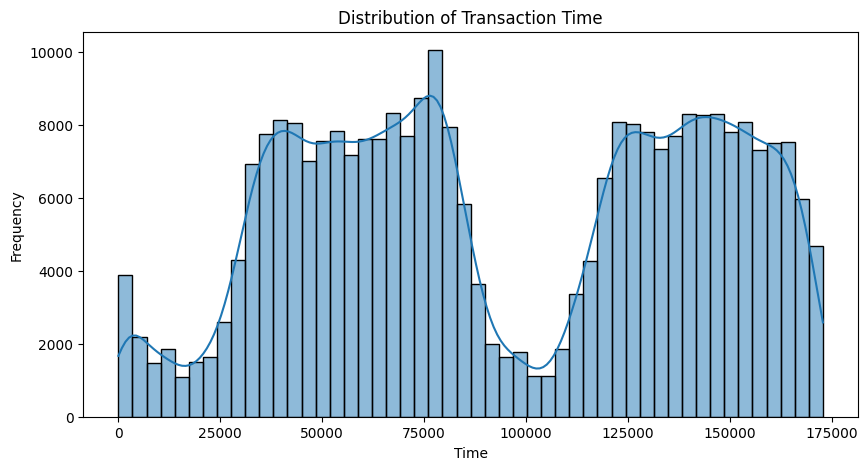

In [11]:
# ==========================================
# Distribution of Transaction Time
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50, kde=True)

plt.title("Distribution of Transaction Time")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

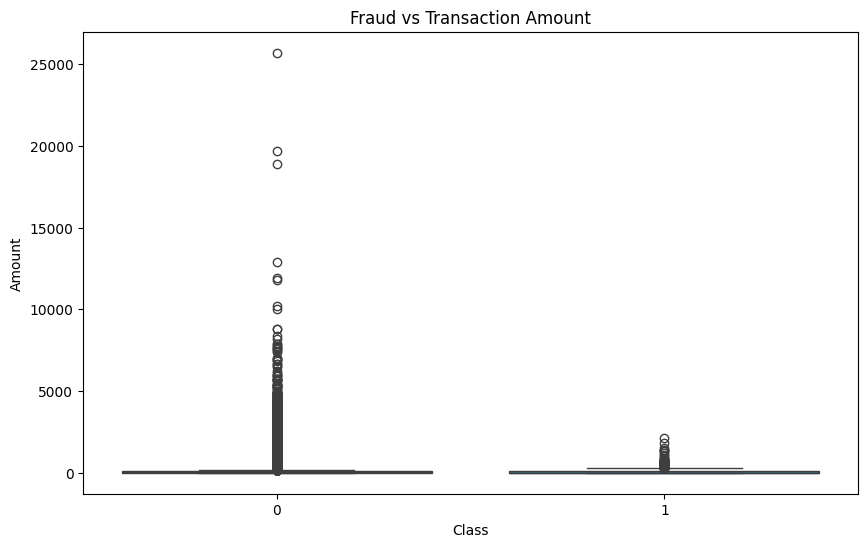

In [12]:
# ==========================================
# Fraud vs Transaction Amount
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(x='Class',
            y='Amount',
            data=df)

plt.title("Fraud vs Transaction Amount")

plt.show()

In [13]:
# ==========================================
# Correlation with Target Variable
# ==========================================

corr = df.corr()['Class'].sort_values(ascending=False)

print(corr)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [14]:
# ==========================================
# Standardize Transaction Amount
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])

# Drop original Amount column
df.drop('Amount', axis=1, inplace=True)

print("Amount feature standardized successfully.")

Amount feature standardized successfully.


In [15]:
# ==========================================
# Rearrange Columns
# ==========================================

scaled_amount = df.pop('Scaled_Amount')

df.insert(1, 'Scaled_Amount', scaled_amount)

df.head()

,Time,Scaled_Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.0,0.244964,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,0.0,-0.342475,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.0,1.160686,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.0,0.140534,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,2.0,-0.073403,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [16]:
# ==========================================
# Separate Features and Target
# ==========================================

X = df.drop('Class', axis=1)

y = df['Class']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (284807, 30)
Target Shape : (284807,)


In [17]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (227845, 30)
Testing Set : (56962, 30)


In [18]:
# ==========================================
# Verify Class Distribution
# ==========================================

print("Training Class Distribution")

print(y_train.value_counts())

print("\nTesting Class Distribution")

print(y_test.value_counts())

Training Class Distribution
Class
0    227451
1       394
Name: count, dtype: int64

Testing Class Distribution
Class
0    56864
1       98
Name: count, dtype: int64


In [20]:
!pip install -q imbalanced-learn xgboost lightgbm tensorflow

In [52]:
# ==========================================
# Import Machine Learning Models
# ==========================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE


In [22]:
# ==========================================
# Evaluation Libraries
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

results = []

In [23]:
# ==========================================
# Model Evaluation Function
# ==========================================

def evaluate_model(model, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Probability scores (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("="*60)
    print(model_name)
    print("="*60)

    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")

    print(confusion_matrix(y_test, y_pred))

In [26]:
logistic = LogisticRegression(max_iter=1000)

evaluate_model(logistic,"Logistic Regression")

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.71      0.77        98

    accuracy                           1.00     56962
   macro avg       0.92      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix
[[56850    14]
 [   28    70]]


In [27]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(decision_tree,"Decision Tree")

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.73      0.74        98

    accuracy                           1.00     56962
   macro avg       0.87      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix
[[56839    25]
 [   26    72]]


In [33]:
RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [34]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

evaluate_model(xgb,"XGBoost")

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix
[[56855     9]
 [   20    78]]


In [35]:
lgbm = LGBMClassifier(
    random_state=42
)

evaluate_model(lgbm,"LightGBM")

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
LightGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.56      0.46        98

    accuracy                           1.00     56962
   macro avg       0.70      0.78      0.73     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix
[[56779    85]
 [   43    55]]


In [36]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.999491,0.896552,0.795918,0.843243,0.922011
0,Logistic Regression,0.999263,0.833333,0.714286,0.769231,0.946847
1,Decision Tree,0.999105,0.742268,0.734694,0.738462,0.867127
3,LightGBM,0.997753,0.392857,0.561224,0.462185,0.726213


In [41]:
# ==========================================
# Import TensorFlow Libraries
# ==========================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

In [42]:
# ==========================================
# Build Artificial Neural Network
# ==========================================

ann = Sequential()

# Input Layer
ann.add(Dense(32,
              activation='relu',
              input_shape=(X_train.shape[1],)))

# Hidden Layer 1
ann.add(Dense(16,
              activation='relu'))

ann.add(Dropout(0.2))

# Hidden Layer 2
ann.add(Dense(8,
              activation='relu'))

# Output Layer
ann.add(Dense(1,
              activation='sigmoid'))

In [43]:
# ==========================================
# Compile ANN
# ==========================================

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [44]:
# ==========================================
# Train ANN
# ==========================================

history = ann.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9941 - loss: 14.0418 - val_accuracy: 0.9982 - val_loss: 0.3544
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9968 - loss: 1.1070 - val_accuracy: 0.9982 - val_loss: 0.0933
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9975 - loss: 0.3636 - val_accuracy: 0.9982 - val_loss: 0.0465
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0579 - val_accuracy: 0.9982 - val_loss: 0.0336
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9978 - loss: 0.2044 - val_accuracy: 0.9982 - val_loss: 0.0170
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0156 - val_accuracy: 0.9982 - val_loss: 0.0136
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0137 - val_accuracy: 0.9982 - val_loss: 0.0140
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0129 - val_accuracy: 0

In [45]:
# ==========================================
# ANN Predictions
# ==========================================

y_prob = ann.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [46]:
# ==========================================
# Evaluate ANN
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("="*60)
print("Artificial Neural Network")
print("="*60)

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))

ann_accuracy = accuracy_score(y_test, y_pred)
ann_precision = precision_score(y_test, y_pred)
ann_recall = recall_score(y_test, y_pred)
ann_f1 = f1_score(y_test, y_pred)
ann_auc = roc_auc_score(y_test, y_prob)

results.append({
    "Model":"Artificial Neural Network",
    "Accuracy":ann_accuracy,
    "Precision":ann_precision,
    "Recall":ann_recall,
    "F1 Score":ann_f1,
    "ROC-AUC":ann_auc
})

Artificial Neural Network
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix
[[56864     0]
 [   98     0]]


In [47]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.999491,0.896552,0.795918,0.843243,0.922011
0,Logistic Regression,0.999263,0.833333,0.714286,0.769231,0.946847
1,Decision Tree,0.999105,0.742268,0.734694,0.738462,0.867127
3,LightGBM,0.997753,0.392857,0.561224,0.462185,0.726213
4,Artificial Neural Network,0.998280,0.000000,0.000000,0.000000,0.505163


In [48]:
# ==========================================
# Apply SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape")

print(X_train.shape)

print(y_train.value_counts())

print("\nAfter SMOTE")

print(X_train_smote.shape)

print(y_train_smote.value_counts())

Original Training Shape
(227845, 30)
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
(454902, 30)
Class
0    227451
1    227451
Name: count, dtype: int64


In [77]:
# ==========================================
# Store SMOTE Results
# ==========================================

smote_results = []

In [78]:
# ==========================================
# Evaluate SMOTE Models
# ==========================================

def evaluate_smote(model, model_name):

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    if hasattr(model,"predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    smote_results.append({

        "Model":model_name,

        "Accuracy":accuracy_score(y_test,y_pred),

        "Precision":precision_score(y_test,y_pred),

        "Recall":recall_score(y_test,y_pred),

        "F1 Score":f1_score(y_test,y_pred),

        "ROC-AUC":roc_auc_score(y_test,y_prob)

    })

    print("="*60)

    print(model_name)

    print("="*60)

    print(classification_report(y_test,y_pred))

In [79]:
logistic = LogisticRegression(
    max_iter=1000
)

evaluate_smote(
    logistic,
    "Logistic Regression"
)

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [80]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

evaluate_smote(
    decision_tree,
    "Decision Tree"
)

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.82      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.91      0.77     56962
weighted avg       1.00      1.00      1.00     56962



In [81]:
random_forest = RandomForestClassifier(
    n_estimators=30,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

evaluate_smote(
    random_forest,
    "Random Forest"
)

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.84      0.75        98

    accuracy                           1.00     56962
   macro avg       0.84      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [82]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

evaluate_smote(
    xgb,
    "XGBoost"
)

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [83]:
lgbm = LGBMClassifier(
    random_state=42
)

evaluate_smote(
    lgbm,
    "LightGBM"
)

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.137678 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.86      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [84]:
# Build ANN for SMOTE Data

ann_smote = Sequential()

ann_smote.add(Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)))
ann_smote.add(Dense(16, activation='relu'))
ann_smote.add(Dropout(0.2))
ann_smote.add(Dense(8, activation='relu'))
ann_smote.add(Dense(1, activation='sigmoid'))

ann_smote.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_smote.fit(
    X_train_smote,
    y_train_smote,
    epochs=10,
    batch_size=256,
    validation_split=0.20,
    verbose=1
)

y_prob = ann_smote.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

smote_results.append({

    "Model":"Artificial Neural Network",

    "Accuracy":accuracy_score(y_test,y_pred),

    "Precision":precision_score(y_test,y_pred),

    "Recall":recall_score(y_test,y_pred),

    "F1 Score":f1_score(y_test,y_pred),

    "ROC-AUC":roc_auc_score(y_test,y_prob)

})

Epoch 1/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6152 - loss: 49.7111 - val_accuracy: 0.0000e+00 - val_loss: 0.9773
Epoch 2/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6250 - loss: 0.6722 - val_accuracy: 0.0000e+00 - val_loss: 0.9808
Epoch 3/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6250 - loss: 0.6628 - val_accuracy: 0.0000e+00 - val_loss: 0.9752
Epoch 4/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6250 - loss: 0.6642 - val_accuracy: 0.0000e+00 - val_loss: 0.9837
Epoch 5/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6248 - loss: 0.6707 - val_accuracy: 0.0000e+00 - val_loss: 0.9849
Epoch 6/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6250 - loss: 0.6622 - val_accuracy: 0.0000e+00 - val_loss: 0.9871
Epoch 7/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6250 - loss: 0.6616 - val_accuracy: 0.0000e+00 - val_loss: 0.9807
Epoch 8/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accu

In [85]:
smote_df = pd.DataFrame(smote_results)

smote_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.999386,0.805825,0.846939,0.825871,0.982010
2,Random Forest,0.999034,0.677686,0.836735,0.748858,0.970041
4,LightGBM,0.998789,0.604317,0.857143,0.708861,0.961451
1,Decision Tree,0.997612,0.404040,0.816327,0.540541,0.907126
0,Logistic Regression,0.988220,0.118509,0.908163,0.209658,0.976274
5,Artificial Neural Network,0.998280,0.000000,0.000000,0.000000,0.500475


In [88]:
# ==========================================
# Add Dataset Labels
# ==========================================

results_df["Dataset"] = "Original"

smote_df["Dataset"] = "SMOTE"

# ==========================================
# Combine Results
# ==========================================

final_results = pd.concat(
    [results_df, smote_df],
    ignore_index=True
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Dataset
0,Logistic Regression,0.999263,0.833333,0.714286,0.769231,0.946847,Original
1,Decision Tree,0.999105,0.742268,0.734694,0.738462,0.867127,Original
2,XGBoost,0.999491,0.896552,0.795918,0.843243,0.922011,Original
3,LightGBM,0.997753,0.392857,0.561224,0.462185,0.726213,Original
4,Artificial Neural Network,0.998280,0.000000,0.000000,0.000000,0.505163,Original


In [89]:
final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Dataset
2,XGBoost,0.999491,0.896552,0.795918,0.843243,0.922011,Original
0,Logistic Regression,0.999263,0.833333,0.714286,0.769231,0.946847,Original
1,Decision Tree,0.999105,0.742268,0.734694,0.738462,0.867127,Original
3,LightGBM,0.997753,0.392857,0.561224,0.462185,0.726213,Original
4,Artificial Neural Network,0.998280,0.000000,0.000000,0.000000,0.505163,Original


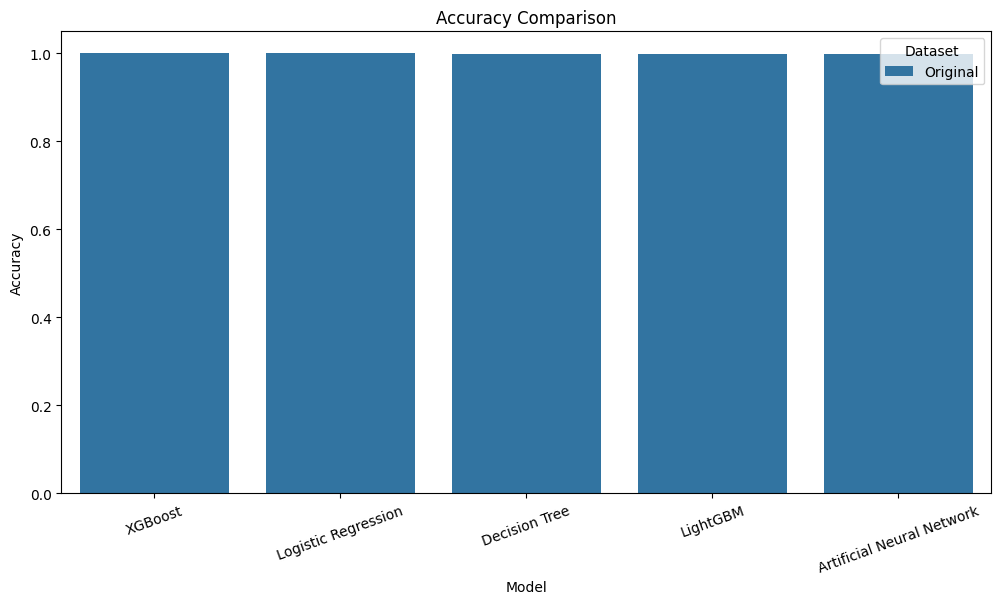

In [90]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison")

plt.show()

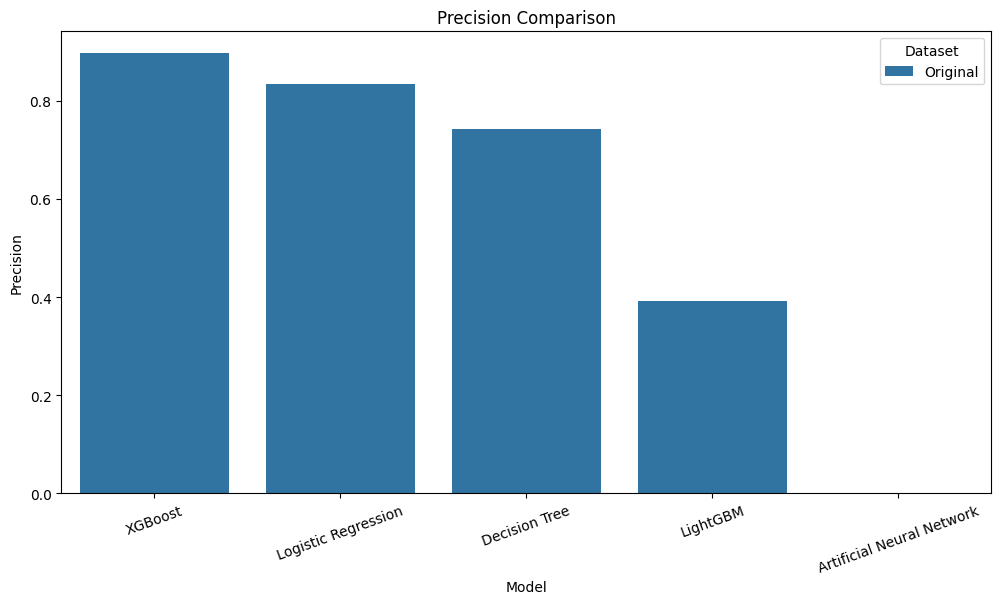

In [91]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Precision",
    hue="Dataset"
)

plt.xticks(rotation=20)

plt.title("Precision Comparison")

plt.show()

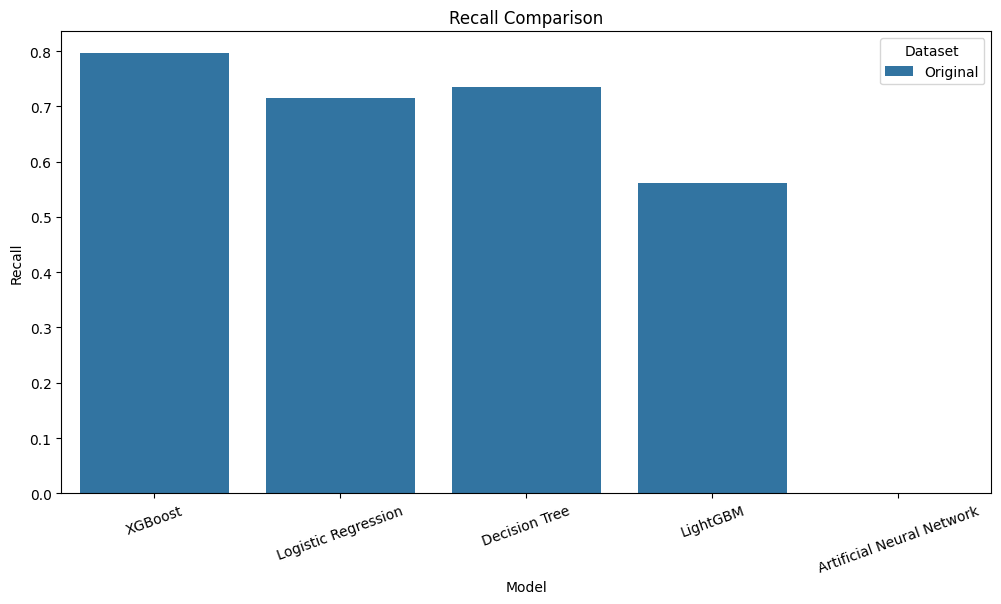

In [92]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Recall",
    hue="Dataset"
)

plt.xticks(rotation=20)

plt.title("Recall Comparison")

plt.show()

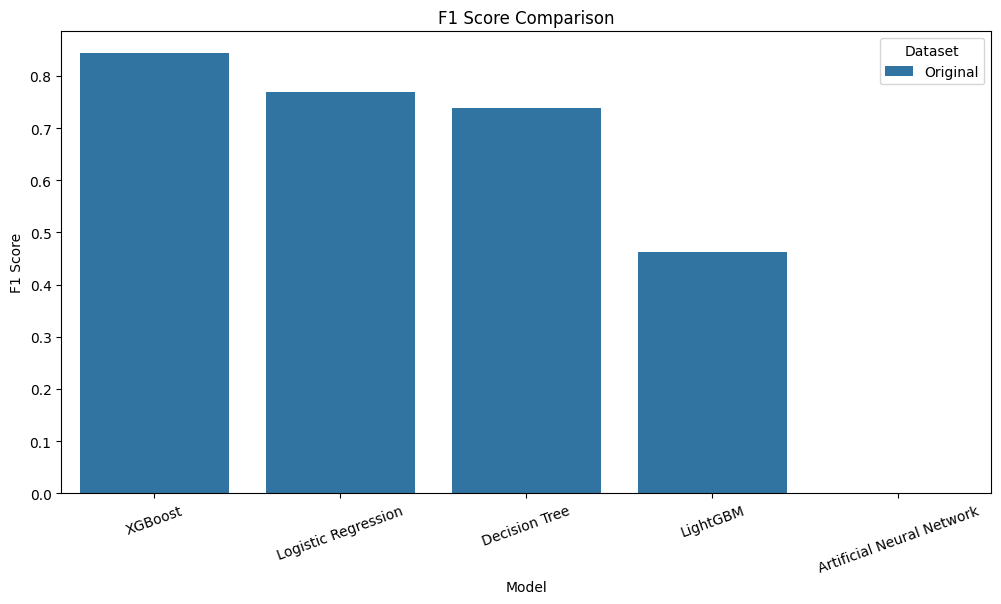

In [93]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="F1 Score",
    hue="Dataset"
)

plt.xticks(rotation=20)

plt.title("F1 Score Comparison")

plt.show()

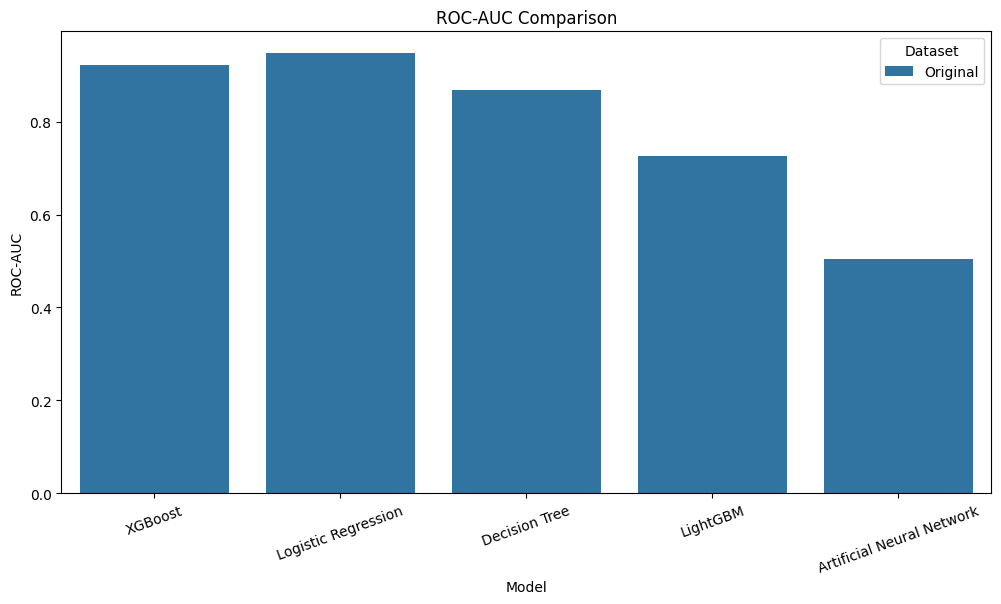

In [94]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="ROC-AUC",
    hue="Dataset"
)

plt.xticks(rotation=20)

plt.title("ROC-AUC Comparison")

plt.show()

In [95]:
print("Best Performing Model")

final_results.head(1)

Best Performing Model


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Dataset
2,XGBoost,0.999491,0.896552,0.795918,0.843243,0.922011,Original


In [96]:
print("="*60)
print("Credit Card Fraud Detection Project Completed Successfully")
print("="*60)

Credit Card Fraud Detection Project Completed Successfully
